# Exploratory Data Analysis - Financial Complaints NLP Dataset

This notebook looks at the processed financial complaints dataset used in this project. I use the EDA to check the data quality, understand the target labels, and decide what should be handled before building a text classification model.

**Dataset:** 162k complaint narratives across 5 product categories  
**Primary task:** classify each complaint narrative into the correct financial product category  
**Main focus:** missing values, class balance, narrative length, useful terms, and modeling risks

## EDA questions

1. Is the dataset clean enough to model?
2. How balanced are the product categories?
3. How long are the complaint narratives?
4. Which words and phrases appear most often by category?
5. Which categories may be harder to separate?
6. What should be considered before training a baseline model?

## 0. Setup

The notebook is designed to run both locally from the repository root and in Google Colab. It searches for `complaints_processed.csv` in the common project locations before loading the data.

In [1]:
from itertools import combinations
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
data_path = '../complaints_processed.csv'

df = pd.read_csv(data_path, index_col=0)
df.columns = df.columns.str.lower()
df = df[['product', 'narrative']].copy()

print(data_path)
print(df.shape)
df.head()

../complaints_processed.csv
(162421, 2)


,product,narrative
0,credit_card,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping rec...
1,credit_card,forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comen...
2,retail_banking,forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actua...
3,credit_reporting,payment history missing credit report specialized loan servicing sl made mistake put account forbearance without aut...
4,credit_reporting,payment history missing credit report made mistake put account forbearance without authorization knowledge matter fa...


## 1. Dataset Overview

This section checks the basic shape of the dataset, missing values, and the product labels.

In [3]:
print('Rows:', len(df))
print('Columns:', df.shape[1])
print('Product categories:', df['product'].nunique())

print()
print('Missing values')
display(df.isna().sum())

print()
print('Duplicate narratives:', df.duplicated(subset='narrative').sum())

product_counts = df['product'].value_counts()
product_share = (product_counts / len(df) * 100).round(2)

display(pd.DataFrame({
    'complaints': product_counts,
    'share_pct': product_share,
}))

Rows: 162421
Columns: 2
Product categories: 5

Missing values


product       0
narrative    10
dtype: int64


Duplicate narratives: 37948


,complaints,share_pct
product,,
credit_reporting,91179,56.14
debt_collection,23150,14.25
mortgages_and_loans,18990,11.69
credit_card,15566,9.58
retail_banking,13536,8.33


**Key observations**

- The dataset is large enough for a strong supervised baseline: 162,421 labeled complaints.
- Missing narratives are negligible, but they should still be dropped before training.
- The target is meaningfully imbalanced: `credit_reporting` dominates the corpus, so accuracy alone would be misleading.
- The project should report macro F1, weighted F1, and a confusion matrix instead of relying only on overall accuracy.

## 2. Data Quality Checks

For text classification, quality issues usually show up as missing text, empty strings, duplicates, extremely short narratives, or unusually long records. These checks define what should be cleaned before modeling.

In [4]:
eda = df.copy()
eda['product'] = eda['product'].astype('string')
eda['text'] = eda['narrative'].fillna('').astype(str).str.strip()
eda['word_count'] = eda['text'].str.split().str.len()
eda['char_count'] = eda['text'].str.len()

checks = pd.Series({
    'missing narrative': df['narrative'].isna().sum(),
    'blank narrative': eda['text'].eq('').sum(),
    'duplicate text': eda.duplicated(subset='text').sum(),
    'under 10 words': (eda['word_count'] < 10).sum(),
    'over 500 words': (eda['word_count'] > 500).sum(),
})

display(pd.DataFrame({
    'count': checks,
    'percent': (checks / len(eda) * 100).round(3),
}))

short_examples = eda.loc[eda['word_count'].between(1, 9), ['product', 'word_count', 'text']]
short_examples.head(8)

,count,percent
missing narrative,10,0.006
blank narrative,10,0.006
duplicate text,37948,23.364
under 10 words,8797,5.416
over 500 words,1759,1.083


,product,word_count,text
76,debt_collection,9,creditor refuse provide income statement account receivable account payable
81,credit_reporting,8,experian reported point loss credit score without reason
85,credit_reporting,9,shocked reviewed credit report found late payment date wfds
431,debt_collection,9,ar account resolution svs licensed collect debt state florida
637,credit_reporting,8,collection remains charge remains charge remains acct remains
646,credit_reporting,6,account credit report reporting seven year
695,retail_banking,6,send deposit wrong account need dispute
698,debt_collection,9,enhancemed recovery company claim owe ive never done business


**Cleaning decision**

- Drop rows with missing or empty narratives.
- Keep duplicate handling as an explicit modeling choice. If duplicates are exact repeats, remove them before splitting to avoid train-test leakage.
- Very short complaints should be reviewed. Some may still contain useful phrases, but they are more likely to be weak training examples.
- Long narratives can stay for TF-IDF baselines, but transformer models may need truncation or chunking.

## 3. Class Distribution

The target label distribution tells us how much imbalance mitigation is needed during training and evaluation.

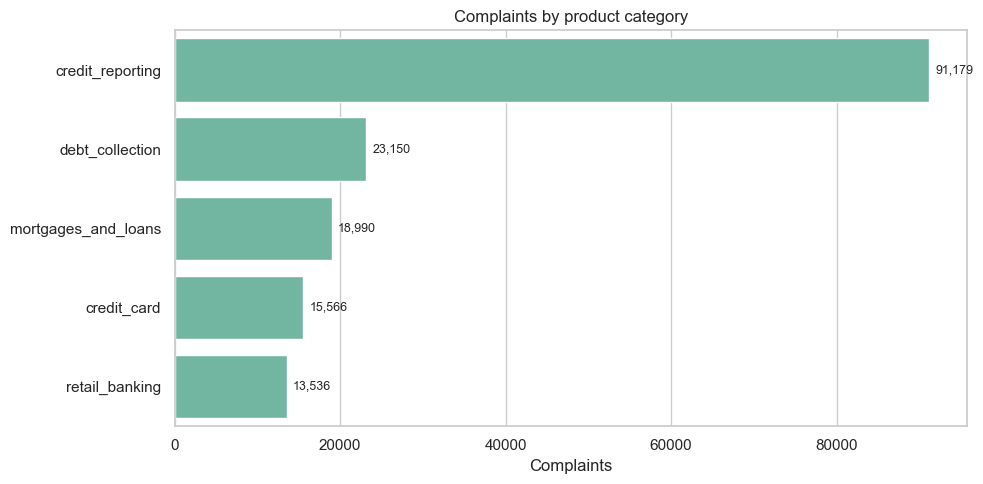

,complaints,share_pct,vs_smallest_class
product,,,
credit_reporting,91179,56.14,6.74
debt_collection,23150,14.25,1.71
mortgages_and_loans,18990,11.69,1.4
credit_card,15566,9.58,1.15
retail_banking,13536,8.33,1.0


Imbalance ratio: 6.7x


In [5]:
counts = eda['product'].value_counts()
imbalance = counts.max() / counts.min()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=counts.values, y=counts.index, ax=ax)
ax.set_title('Complaints by product category')
ax.set_xlabel('Complaints')
ax.set_ylabel('')

for row, value in enumerate(counts.values):
    ax.text(value + 750, row, f'{value:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

class_dist = pd.DataFrame({
    'complaints': counts,
    'share_pct': (counts / len(eda) * 100).round(2),
    'vs_smallest_class': (counts / counts.min()).round(2),
})

display(class_dist)
print(f'Imbalance ratio: {imbalance:.1f}x')

**Modeling implication**

`credit_reporting` accounts for more than half of the dataset. A model can look strong by over-predicting the majority class, so downstream experiments should use stratified splits, class weights or resampling, and macro-averaged metrics.

## 4. Narrative Length Analysis

Text length affects feature extraction, model runtime, truncation strategy, and the quality of learned representations.

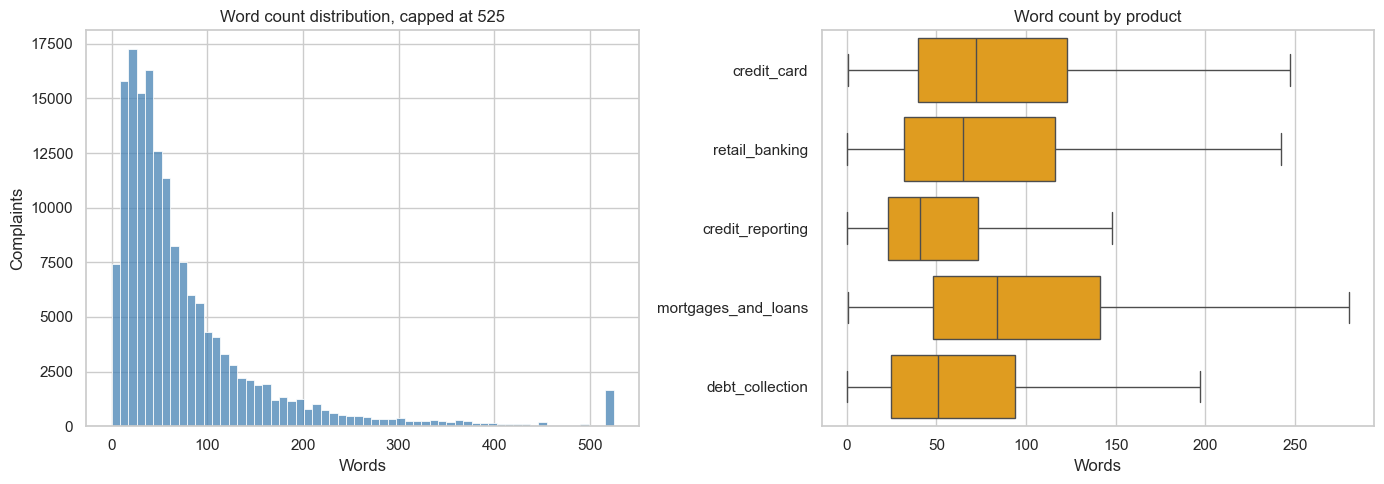

In [6]:
length_by_product = (
    eda
    .groupby('product')
    .agg(
        complaints=('product', 'size'),
        median_words=('word_count', 'median'),
        mean_words=('word_count', 'mean'),
        p90_words=('word_count', lambda s: s.quantile(0.90)),
        max_words=('word_count', 'max'),
    )
    .round(1)
    .sort_values('median_words', ascending=False)
)

length_by_product

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99_words = int(eda['word_count'].quantile(0.99))
sns.histplot(eda['word_count'].clip(upper=p99_words), bins=60, ax=axes[0], color='steelblue')
axes[0].set_title(f'Word count distribution, capped at {p99_words}')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Complaints')

sns.boxplot(data=eda, x='word_count', y='product', ax=axes[1], showfliers=False, color='orange')
axes[1].set_title('Word count by product')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Length takeaways**

- Complaint narratives are generally short enough for TF-IDF and classical ML baselines.
- The right tail matters: very long complaints may exceed transformer context limits and require truncation or chunking.
- Length can itself be a useful diagnostic feature because complex products such as mortgages and loans often require longer explanations.

## 5. High-Signal Terms and Phrases

Because the text is already processed, the most useful signal comes from category-specific terms and bigrams rather than generic words like `account`, `payment`, or `credit`. TF-IDF helps surface phrases that are frequent within a category but less common across the full corpus.

product,credit_card,credit_reporting,debt_collection,mortgages_and_loans,retail_banking
rank,,,,,
1,card,credit,debt,loan,bank
2,credit,account,collection,payment,account
3,credit card,report,credit,mortgage,money
4,payment,credit report,account,month,fund
5,account,information,company,time,pnc
6,charge,reporting,report,told,check
7,bank,inquiry,credit report,company,paypal
8,time,item,letter,pay,transaction
9,called,bureau,information,bank,deposit


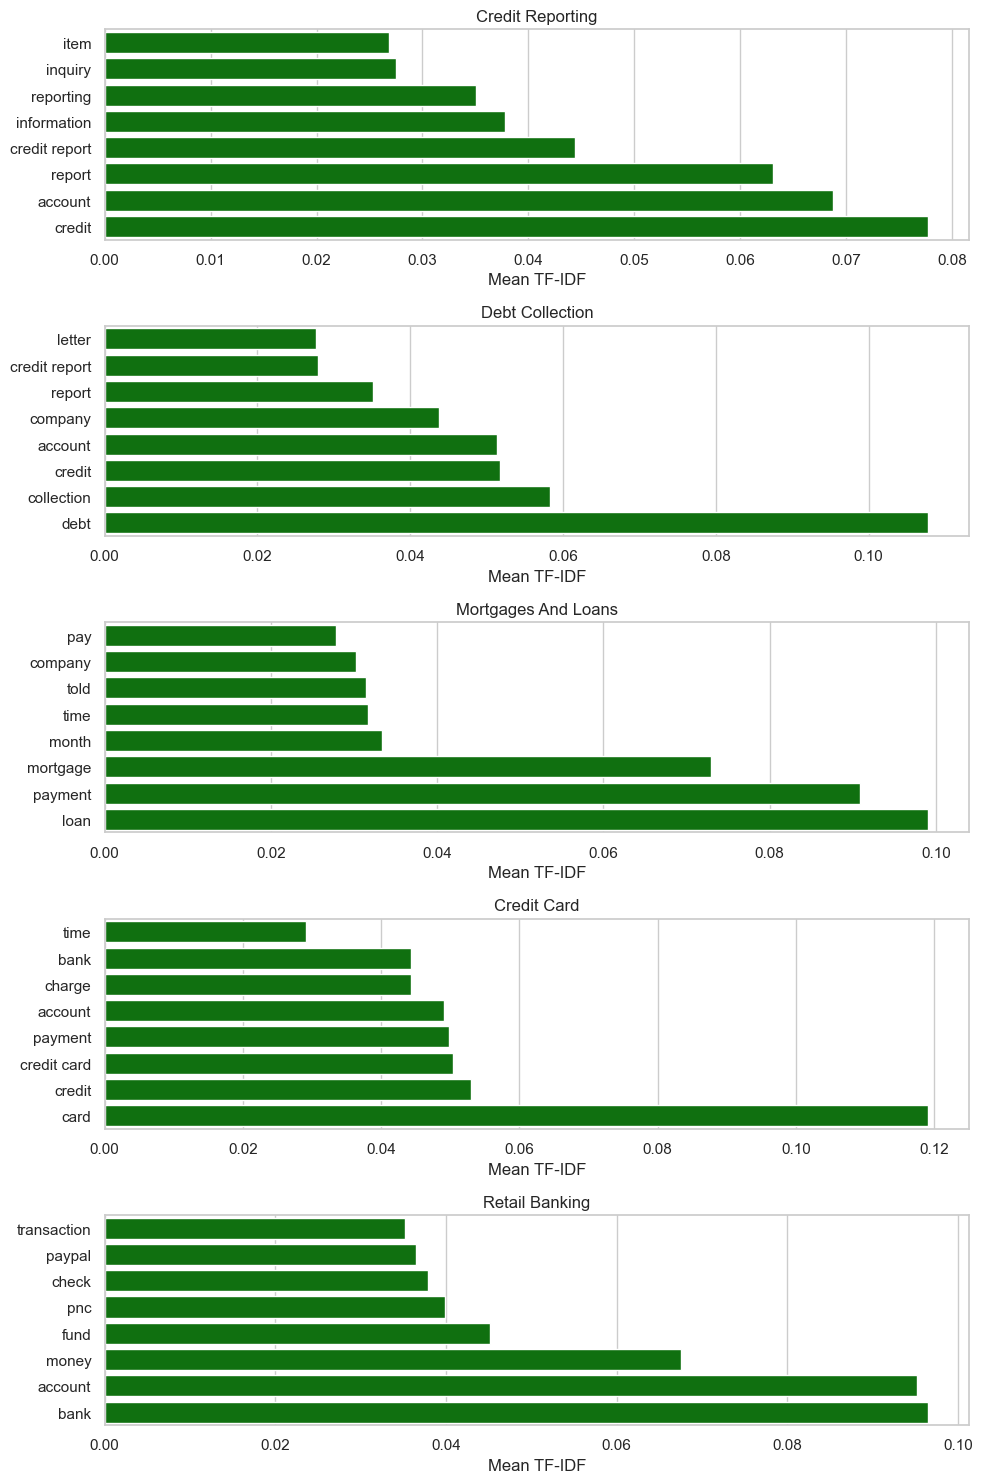

In [7]:
clean = eda[eda['text'].ne('')].copy()

vec = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=8,
    max_df=0.85,
    max_features=5000,
    stop_words='english',
)

X = vec.fit_transform(clean['text'])
terms = np.array(vec.get_feature_names_out())

top_terms = []
term_sets = {}

for product in counts.index:
    product_rows = clean['product'].eq(product).to_numpy()
    scores = np.asarray(X[product_rows].mean(axis=0)).ravel()
    top_idx = scores.argsort()[-15:][::-1]
    term_sets[product] = set(terms[top_idx[:50]])

    for rank, idx in enumerate(top_idx, 1):
        top_terms.append({
            'product': product,
            'rank': rank,
            'term': terms[idx],
            'score': scores[idx],
        })

top_terms = pd.DataFrame(top_terms)
display(top_terms.pivot(index='rank', columns='product', values='term').head(12))

terms_to_plot = top_terms[top_terms['rank'] <= 8].copy()

fig, axes = plt.subplots(len(counts), 1, figsize=(10, 15))
for ax, product in zip(axes, counts.index):
    subset = terms_to_plot[terms_to_plot['product'].eq(product)].sort_values('score')
    sns.barplot(data=subset, x='score', y='term', ax=ax, color='green')
    ax.set_title(product.replace('_', ' ').title())
    ax.set_xlabel('Mean TF-IDF')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

**Term-signal takeaways**

- Bigrams are essential because phrases such as `credit report`, `collection agency`, `bank account`, and `loan modification` carry more meaning than isolated tokens.
- The categories with very distinct terms should be easier for a baseline classifier to learn.
- Categories with shared banking/payment vocabulary need careful confusion-matrix review after modeling.

## 6. Category Overlap Risk

This is a lightweight proxy for likely model confusion. If two classes share many of their top TF-IDF terms, a classifier may need more context to separate them.

In [8]:
pairs = []
for left, right in combinations(counts.index, 2):
    shared_terms = term_sets[left] & term_sets[right]
    all_terms = term_sets[left] | term_sets[right]
    pairs.append({
        'pair': f'{left} vs {right}',
        'shared_terms': len(shared_terms),
        'jaccard': round(len(shared_terms) / len(all_terms), 3),
        'examples': ', '.join(sorted(shared_terms)[:8]),
    })

pd.DataFrame(pairs).sort_values('jaccard', ascending=False)

,pair,shared_terms,jaccard,examples
0,credit_reporting vs debt_collection,6,0.250,"account, credit, credit report, information, letter, report"
7,mortgages_and_loans vs credit_card,6,0.250,"account, bank, called, payment, time, told"
9,credit_card vs retail_banking,5,0.200,"account, bank, card, chase, told"
4,debt_collection vs mortgages_and_loans,5,0.200,"account, company, paid, received, time"
8,mortgages_and_loans vs retail_banking,3,0.111,"account, bank, told"
2,credit_reporting vs credit_card,3,0.111,"account, credit, payment"
5,debt_collection vs credit_card,3,0.111,"account, credit, time"
1,credit_reporting vs mortgages_and_loans,2,0.071,"account, payment"
3,credit_reporting vs retail_banking,2,0.071,"account, day"
6,debt_collection vs retail_banking,1,0.034,account


**Interpretation**

Pairs with higher overlap should be inspected in the model confusion matrix. If overlap is high, richer features may help: bigrams/trigrams, character n-grams, domain-specific features, or embeddings from a transformer model.

## 7. Word Clouds by Product Category

Word clouds are mainly a quick visual check. They make it easier to scan the most common terms for each product category.

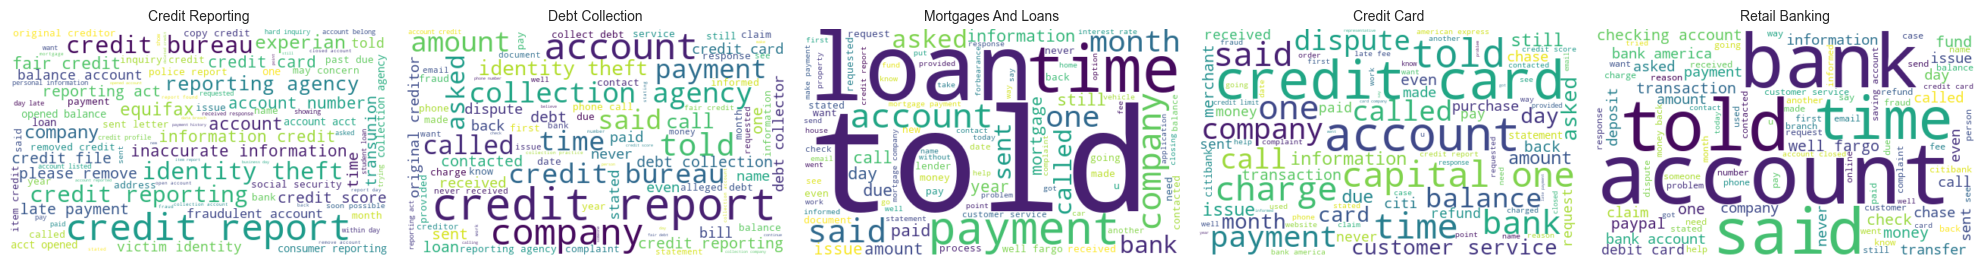

In [9]:
fig, axes = plt.subplots(1, len(counts), figsize=(20, 4))

for ax, product in zip(axes, counts.index):
    text_sample = ' '.join(
        clean.loc[clean['product'].eq(product), 'text']
        .sample(min(5000, counts[product]), random_state=42)
    )

    wc = WordCloud(
        width=500,
        height=300,
        background_color='white',
        max_words=90,
        collocations=True,
        random_state=42,
    ).generate(text_sample)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(product.replace('_', ' ').title(), fontsize=10)

plt.tight_layout()
plt.show()

## 8. Modeling Recommendations

Based on the EDA, I would use the following setup for the next modeling step:

- **Cleaning:** drop missing/empty narratives and consider removing exact duplicate narratives before splitting.
- **Split strategy:** use a stratified train/validation/test split to preserve minority classes.
- **Baseline:** start with TF-IDF using unigrams and bigrams plus Logistic Regression or Linear SVM.
- **Imbalance handling:** use `class_weight='balanced'` or compare with resampling methods.
- **Evaluation:** report macro F1, weighted F1, per-class precision/recall, and a confusion matrix.
- **Feature strategy:** keep bigrams because phrase-level terms are more informative than single words.
- **Next step:** use the classifier results to route complaints by product category and review errors by class.

## 9. EDA Summary for the Project README

This compact summary can be reused in the README or project report.

In [10]:
print(f'Total complaints: {len(eda):,}')
print(f'Product categories: {eda["product"].nunique()}')
print(f'Largest class: {counts.idxmax()} ({counts.max():,})')
print(f'Smallest class: {counts.idxmin()} ({counts.min():,})')
print(f'Imbalance ratio: {imbalance:.1f}x')
print(f'Median words: {eda["word_count"].median():.0f}')
print(f'Missing narratives: {df["narrative"].isna().sum():,}')

Total complaints: 162,421
Product categories: 5
Largest class: credit_reporting (91,179)
Smallest class: retail_banking (13,536)
Imbalance ratio: 6.7x
Median words: 50
Missing narratives: 10


## 10. Final Takeaways

The dataset has enough rows and clear labels for a solid NLP classification baseline. The main issues to handle are class imbalance, possible duplicate leakage, and overlap between banking-related categories. The next step is to train a transparent baseline model, evaluate it with class-aware metrics, and use the confusion matrix to decide where the model needs improvement.